**Task 2: Quantitative analysis using pynance and TaLib**

Objective: Load historical stock price data, compute financial technical indicators, and
visualize the results to understand market behavior.


In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))

1. Prepare Your Data


In [2]:
# Import your custom modules
from src.data_loader import load_stock_data, process_financial_data

# Define file path
meta_path = "../data/raw/meta.csv"

# Load raw dataset
print("Loading raw data for meta...")
raw_meta = load_stock_data(meta_path)

# Clean dataset
print("Applying financial cleaning rules...")
clean_meta = process_financial_data(raw_meta)


# Check data types
print(clean_meta.dtypes)

# Missing values
print("Missing Values Remaining")
print(clean_meta.isnull().sum())

# Preview dataset
print("Preview of the Clean meta Dataset")
print(clean_meta.head())

Loading raw data for meta...
Applying financial cleaning rules...
Date      datetime64[us, UTC]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
dtype: object
Missing Values Remaining
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Preview of the Clean meta Dataset
                       Date      Close       High        Low       Open  \
0 2012-05-18 00:00:00+00:00  37.995762  44.724282  37.767172  41.792356   
1 2012-05-21 00:00:00+00:00  33.821495  36.435382  32.797807  36.306177   
2 2012-05-22 00:00:00+00:00  30.810066  33.384198  30.750434  32.410203   
3 2012-05-23 00:00:00+00:00  31.803938  32.300874  31.167860  31.177799   
4 2012-05-24 00:00:00+00:00  32.827625  33.006523  31.575347  32.748117   

      Volume  
0  573576400  
1  168192700  
2  101786600  
3   73600000  
4   50237200  


**2. Compute Technical Indicators with TA-Lib**

In [3]:
from src.indicators import add_moving_averages, add_rsi, add_macd, add_financial_metrics

print("Computing technical indicators for meta...")

# Apply the mathematical transformations sequentially
clean_meta = add_moving_averages(clean_meta)
clean_meta = add_rsi(clean_meta)
clean_meta = add_macd(clean_meta)

# Apply the financial metrics (This creates the 'Daily_Return' column!)
clean_meta = add_financial_metrics(clean_meta)

print(" Indicators computed successfully! Previewing results:")
clean_meta[
    [
        'Date', 
        'Close', 
        'SMA_20', 
        'RSI', 
        'MACD', 
        'Daily_Return'
    ]
].tail()

2026-05-10 13:22:56,983 - WARNING - PyNance calculation skipped: module 'pynance' has no attribute 'tech'


Computing technical indicators for meta...
 Indicators computed successfully! Previewing results:


,Date,Close,SMA_20,RSI,MACD,Daily_Return
2918,2023-12-22 00:00:00+00:00,351.224823,332.302945,67.333885,6.945367,-0.001977
2919,2023-12-26 00:00:00+00:00,352.655975,333.303278,68.187000,7.436800,0.004075
2920,2023-12-27 00:00:00+00:00,355.637543,334.239505,69.947874,7.974921,0.008455
2921,2023-12-28 00:00:00+00:00,356.124634,335.537503,70.237702,8.344500,0.001370
2922,2023-12-29 00:00:00+00:00,351.791290,336.869788,64.296803,8.193282,-0.012168


**Apply PyNance for Financial Metrics**

In [4]:
from src.financial_metrics import add_financial_metrics

clean_meta = add_financial_metrics(clean_meta)

# Pass the analyzed_meta dataframe you generated in the previous step
clean_meta = add_financial_metrics(clean_meta)
print("Metrics computed successfully!")
clean_meta[['Date', 'Returns', 'Volatility_20', 'Cumulative_Return']].tail()

Metrics computed successfully!


,Date,Returns,Volatility_20,Cumulative_Return
2918,2023-12-22 00:00:00+00:00,-0.001977,0.016090,9.243789
2919,2023-12-26 00:00:00+00:00,0.004075,0.015809,9.281456
2920,2023-12-27 00:00:00+00:00,0.008455,0.015697,9.359927
2921,2023-12-28 00:00:00+00:00,0.001370,0.014758,9.372746
2922,2023-12-29 00:00:00+00:00,-0.012168,0.014566,9.258698


**Visualize the Data**


Generating Price & Moving Averages Chart...


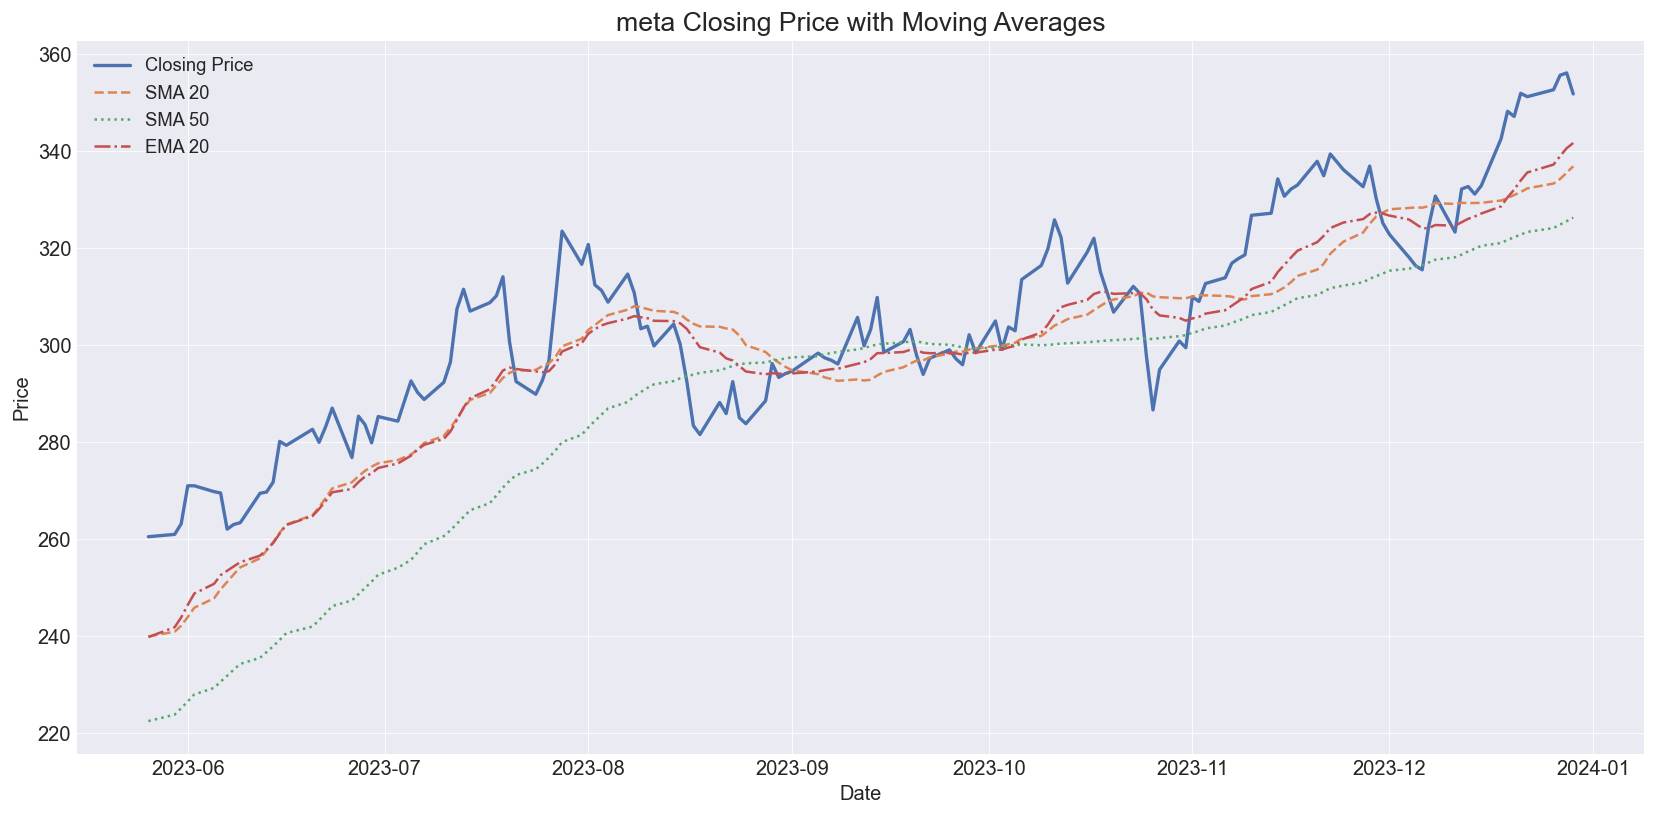

In [5]:
from src.visuals import set_visual_style, plot_price_and_ma, plot_rsi, plot_macd

# Apply the global darkgrid style
set_visual_style()

symbol = 'meta'

# 1. Plot Price and Moving Averages
print("Generating Price & Moving Averages Chart...")
plot_price_and_ma(clean_meta, symbol)

Generating RSI Chart...


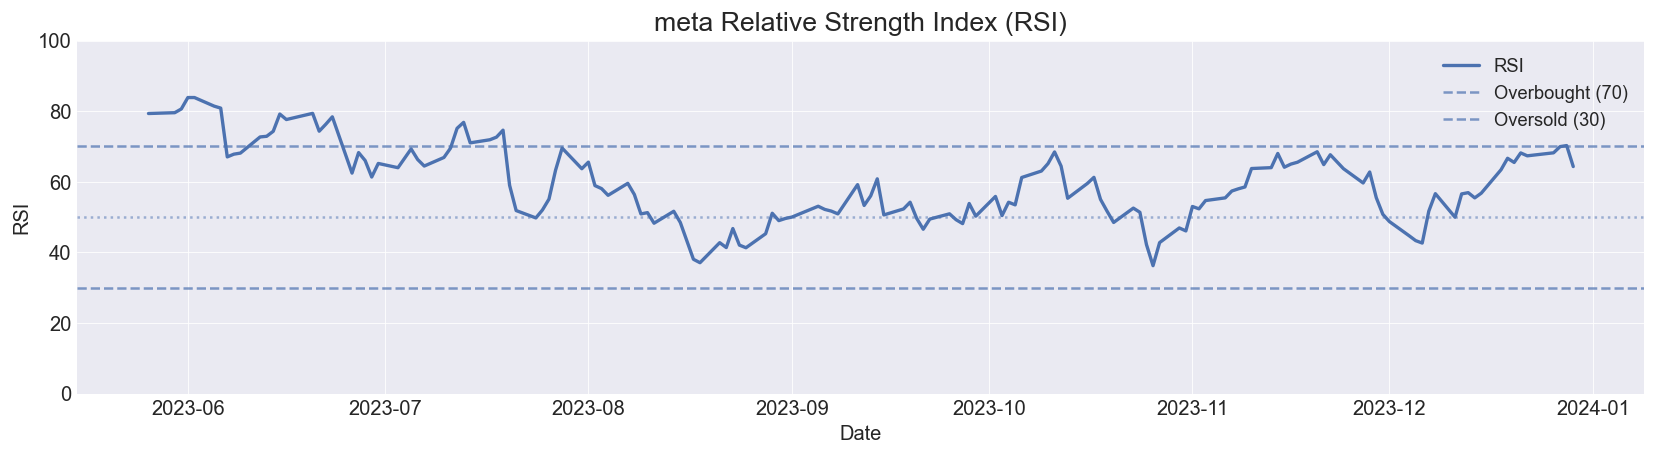

In [6]:
# 2. Plot Relative Strength Index
print("Generating RSI Chart...")
plot_rsi(clean_meta, symbol)

Generating MACD Chart...


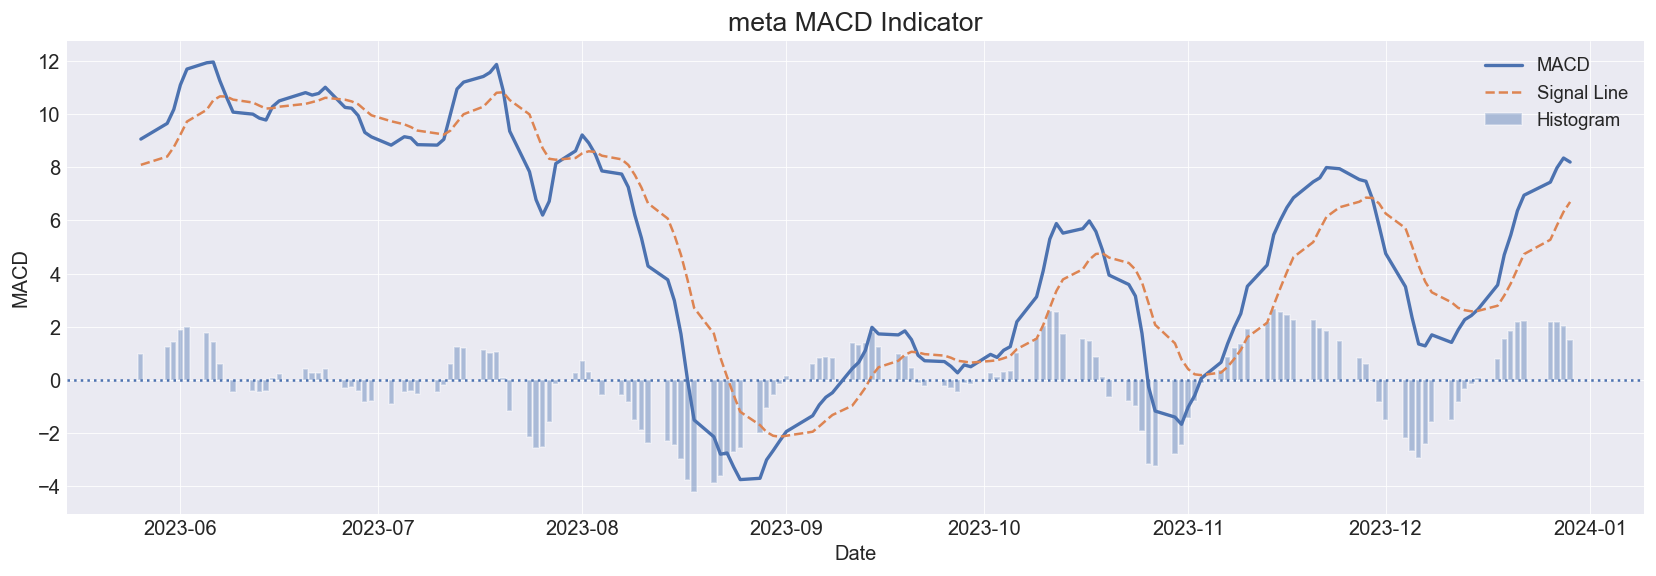

In [7]:
# 3. Plot MACD
print("Generating MACD Chart...")
plot_macd(clean_meta, symbol)

In [8]:
# save the processed dataset for task 3
import os

# Ensure the directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save the finalized dataset
processed_meta_path = f"../data/processed/{symbol}_processed.csv"
clean_meta.to_csv(processed_meta_path, index=False)

print(f" {symbol} quantitative analysis complete and saved to {processed_meta_path}")

 meta quantitative analysis complete and saved to ../data/processed/meta_processed.csv
